In [2]:
import os
import re
import json

from faiss.contrib.torch_utils import torch_replacement_pairwise_distance_gpu
from typing_extensions import List, TypedDict, Annotated, Any
from dotenv import load_dotenv
import operator

from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings

from langchain_anthropic import ChatAnthropic

from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever
from langchain_community.vectorstores import FAISS

from langchain.vectorstores import DocArrayInMemorySearch
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import AnyMessage, HumanMessage, RemoveMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import tool

from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.chains.llm import LLMChain
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Send

load_dotenv()

True

Utils Functions

In [3]:
###Extract output from tags in string format
def extract_json_output(response: str):
    json_match = re.search(r"<output>(.*?)</output>", response, re.DOTALL)
    json_string = json_match.group(1).strip()
    parsed_json = json.loads(json_string)
    return parsed_json


###Extract output from tags in string format
def extract_str_output(response: str):
    str_match = re.search(r"<output>(.*?)</output>", response, re.DOTALL)
    str_string = str_match.group(1).strip()
    return str_string

LangGraph States

In [4]:
class OverallState(MessagesState):
    questions: Annotated[List[HumanMessage], operator.add]
    llms_responses: Annotated[List[Any], operator.add]
    end_responses: Annotated[List[str], operator.add]
    retrieved_documents: List[Document]
    attempt: int
    summary: str

class OneLLMState(TypedDict):
    messages_one_llm: Annotated[List[AnyMessage], operator.add]
    llm_responses: Annotated[List[AnyMessage], operator.add]
    llm: Any
    user_question: str

class OneQuestionResponseState(TypedDict):
    messages_one_answer: Annotated[List[AnyMessage], operator.add]
    response: AnyMessage
    llm: Any
    user_question: str

Initialization

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY"))
llm1 = ChatOpenAI(model="gpt-4o", api_key=os.getenv("OPENAI_API_KEY"))
llm2 = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY"))
llm3 = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY"))
# llm3 = ChatAnthropic(model="claude-3-5-sonnet-20241022", api_key=os.getenv("ANTHROPIC_API_KEY"))
llms = [llm1, llm2, llm3]

In [6]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large", api_key=os.getenv("OPENAI_API_KEY"))
loader = PyPDFLoader(file_path="data/AML_IEEE_ACCESS_2024.pdf", extract_images=True)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=3500, chunk_overlap=0)
docs = loader.load()
all_splits = text_splitter.split_documents(docs)
full_document_content = "\n\n".join(doc.page_content for doc in docs)

In [7]:
# Define prompt
prompt = ChatPromptTemplate.from_messages(
    [("system", "Write a concise summary of the following:\\n\\n{context}")]
)

# Instantiate chain
chain = create_stuff_documents_chain(llm, prompt)

# Invoke chain
result = chain.invoke({"context": docs})

In [8]:
for doc in all_splits:
    doc.metadata['summary'] = result

In [9]:
DOCUMENT_CONTEXT_PROMPT = """
<document>
{doc_content}
</document>
"""

CHUNK_CONTEXT_PROMPT = """
Here is the chunk we want to situate within the whole document
<chunk>
{chunk_content}
</chunk>

Please give a short succinct context to situate this chunk within the overall document for the purposes of improving search retrieval of the chunk.
Answer only with the succinct context and nothing else.
"""



context_create_chain = llm | StrOutputParser()

In [13]:
# for i, split in enumerate(all_splits):
#     messages=[
#         
#             {
#                 "role": "user", 
#                 "content": [
#                     {
#                         "type": "text",
#                         "text": DOCUMENT_CONTEXT_PROMPT.format(doc_content=all_splits),
#                         "cache_control": {"type": "ephemeral"} #we will make use of prompt caching for the full documents
#                     },
#                     {
#                         "type": "text",
#                         "text": CHUNK_CONTEXT_PROMPT.format(chunk_content=split.page_content),
#                     }
#                 ]
#             }
#         ]
#     response = context_create_chain.invoke(messages)
#     all_splits[i].page_content += "/n" + response
#     print(i)

In [12]:
# initialize the bm25 retriever and faiss retriever
bm25_retriever = BM25Retriever.from_documents(
    all_splits
)
bm25_retriever.k = 2
embedding = OpenAIEmbeddings()
faiss_vectorstore = FAISS.from_documents(
    all_splits, embedding
)
faiss_retriever = faiss_vectorstore.as_retriever(search_kwargs={"k": 2})

# initialize the ensemble retriever
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever], weights=[0.5, 0.5]
)

db = DocArrayInMemorySearch.from_documents(all_splits, embeddings)
retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": 2})

memory = MemorySaver()

/Users/tsan-yuwu/PycharmProjects/magic-conches/.venv/lib/python3.10/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


Tools

In [13]:
@tool(response_format="content_and_artifact")
def retrieve(query: str):
    """
    If the user has a question, you should extract the question and call this function.
    Args:
        query (str): User Question.
    """
    retrieved_docs = ensemble_retriever.invoke(query)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

Single LLM LangGraph Nodes

In [14]:
def single_llm_invoke(state: OneLLMState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages_one_llm"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    prompt = PromptTemplate.from_template("""
    You are an assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer the question. Use three sentences maximum and keep the answer concise.
     Here is retrieved documents:
    <documents>
    {documents}
    </documents>

    And here is the initial query from the user:

    <question>
    {query} 
    </question>
    """
                                          )
    question = state["user_question"]

    chain = prompt | state["llm"] | StrOutputParser()
    # Run
    response = chain.invoke({"documents": tool_messages, "query": question})
    return {
        "llms_responses": [
            {
                "model": getattr(state["llm"], "model_name", "model"),
                "response": response
            }
        ]
    }

subgraph_builder = StateGraph(OneLLMState, output=OverallState)
subgraph_builder.add_node("Single LLM Invoke", single_llm_invoke)
subgraph_builder.add_edge(START, "Single LLM Invoke")
subgraph_builder.add_edge("Single LLM Invoke", END)


In [135]:
def generate_feedback_or_not(state: OverallState):
    prompt = PromptTemplate.from_template(
        """
        Your task is to determine, if the user wants to generate final feedback or not
        Here is the user question:
        <question>
        {query}
        </question>
        After your assessment, provide your final decision in JSON format. The JSON must contain a single key "feedback" with a value of either "yes" or "no". For example:

        {{
          "feedback": "yes"
        }}

        or

        {{
          "feedback": "no"
        }}

        Wrap your answer in <output> tag.
        """
    )

    chain = prompt | llm | StrOutputParser()
    question = state["questions"][-1]

    response = chain.invoke({"query": question})
    response_json = extract_json_output(response)

    if "yes" == response_json["feedback"]:
        return "no"
    if "no" == response_json["feedback"]:
        return "no"

def retrieve_or_not(state: OverallState):
    user_message = {"role": "user", "content": state["questions"][-1]}
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke([user_message])
    if len(response.tool_calls) == 0:
        return {"messages": [response], "end_responses": [response.content]}
    else:
        if "attempt" in state:
            return {"messages": [response], "attempt": state["attempt"]}
        return {"messages": [response], "attempt": 1}
        

tools = ToolNode([retrieve])

def evaluate_documents(state: OverallState, max_retries=2):
    prompt = PromptTemplate.from_template(
        """
        You are an expert document assessor tasked with determining the relevance of a retrieved document to a user's question. Your goal is to provide an accurate relevance assessment based on both keyword matches and semantic understanding.

        First, carefully review the following information:

        1. Retrieved Documents:
        <retrieved documents>
        {documents}
        </retrieved documents>

        2. Here is the user question:
        <question>
        {query}
        </question>

        Your task is to determine whether the retrieved document is relevant to the user's question. Follow these steps:

        1. Analyze the document and question for keyword matches and semantic relevance.
        2. Consider any information in the document that could be helpful in answering the user's question, even if it's not a direct match.
        3. Make a decision on relevance, erring on the side of relevance if there's any doubt.
        4. Provide your assessment in the specified JSON format.

        Before making your final decision, wrap your thought process in <relevance_assessment> tags:

        <relevance_assessment>
        1. Quote any relevant parts of the document and the question, highlighting keyword matches.
        2. Describe any semantic connections or relevant information found in the document.
        3. List arguments for considering the document relevant.
        4. List arguments for considering the document not relevant.
        5. Explain your reasoning for your final decision on relevance.
        </relevance_assessment>

        After your assessment, provide your final decision in JSON format. The JSON must contain a single key "relevant" with a value of either "yes" or "no". For example:

        {{
          "relevant": "yes"
        }}

        or

        {{
          "relevant": "no"
        }}

        Remember, it's important to consider both direct keyword matches and broader semantic relevance. If the document contains any information that could be helpful in addressing the user's question, even indirectly, it should be considered relevant.

        Wrap your answer in <output> tag.
        """
    )

    parser = StrOutputParser()

    chain = prompt | llm | parser

    question = state["questions"][-1]
    documents = state["messages"][-1].content
    response = chain.invoke(
        {
            "documents": documents,
            "query": question,
        }
    )

    filtered_response = extract_json_output(response)
    if filtered_response["relevant"] == "yes" or state["attempt"] >= 2:
        return [Send("Single LLM Process Start",
                 {"messages_one_llm": state["messages"], "response": "", "user_question": state["questions"][-1],
                  "llm": llm}) for llm in llms]
    elif filtered_response["relevant"] == "no":
        del state["messages"][-1]
        return "Rewrite User Question"

def rewrite_user_question(state: OverallState):
    prompt = PromptTemplate.from_template(
        """
        You are an advanced language model tasked with improving user queries to enhance document retrieval and overall conversation quality. Your goal is to analyze the initial query and conversation history, understand the underlying semantic intent, and formulate an improved question.

        Here is the history of the conversation:

        <conversation_history>
        {messages}
        </conversation_history>

        And here is the initial query from the user:

        <initial_query>
        {query}
        </initial_query>

        Please follow these steps to formulate an improved question:

        1. Analyze the conversation history and initial query.
        2. Identify the underlying semantic intent or meaning behind the user's question.
        3. Consider any additional context or information provided in the conversation history that could help clarify or refine the query.
        4. Formulate an improved question that:
           - Captures the core intent of the original query
           - Incorporates relevant context from the conversation history
           - Is more precise, clear, and likely to yield better document retrieval results
           - Maintains the original topic and purpose of the query

        Before providing the final improved question, please wrap your thought process inside <query_improvement_process> tags. This will help ensure a thorough interpretation of the query and conversation context. In this process:

        1. Identify and list key topics/themes from the conversation history.
        2. Quote relevant parts of the conversation history that provide context for the query.
        3. Break down the initial query into its core components.
        4. Consider how the conversation history might influence or refine each component of the query.
        5. Explain how you arrived at the improved question based on this analysis.

        Output Format:
        After your analysis, provide only the improved question wrapped in <output> without any additional explanation or text.

        Example output structure:

        <query_improvement_process>
        [Your detailed analysis of the conversation history and initial query, following the steps outlined above]
        </query_improvement_process>

        <output>
        [Improved question goes here, without any tags or additional text]
        </output>

        Please proceed with your query improvement process and improved question formulation.      
        """
    )

    parser = StrOutputParser()
    chain = prompt | llm | parser

    question = state["questions"][-1]
    messages = state["summary"]

    response = chain.invoke(
        {
            "messages": messages,
            "query": question,
        }
    )

    del state["questions"][-1]

    return {"messages": [HumanMessage(content=extract_str_output(response))],
            "questions": [extract_str_output(response)], "attempt": state["attempt"] + 1}

def start_generate_llms(state: OverallState):
    return {}

def continue_to_generate_llms(state: OverallState):
    return [Send("Single LLM Process Start",
                 {"messages_one_llm": state["messages"], "response": "", "user_question": state["questions"][-1],
                  "llm": llm}) for llm in llms]

def end_response(state: OverallState):
    """
    This function combines the last three LLM responses into a single formatted string,
    saves it in `state["end_responses"]`, and clears the `state["messages"]`.
    """
    # Retrieve the last three responses from llm_responses
    responses = state["llms_responses"][-3:]

    # Create a combined response string
    combined_response = "\n ".join(
        [f"{i + 1}) Answer of {response['model']} : {response['response']}" for i, response in enumerate(responses)]
    )

    # Save the combined response in state["end_responses"]
    state["end_responses"] = [combined_response]

    # Clear the messages in state
    state["messages"] = [RemoveMessage(id=m.id) for m in state["messages"]]

    return {"end_responses": state["end_responses"], "messages": state["messages"]}


def generate_feedback(state: OverallState):
    """
    Generate Feedback
    :param state: 
    :return: 
    """
def generate_summary(state: OverallState):
    # First, we get any existing summary
    # summary = state.get("summary", "")

    # Create our summarization prompt
    # if summary:
    #
    #     # A summary already exists
    #     summary_message = (
    #         f"This is summary of the conversation to date: {summary}\n\n"
    #         "Extend the summary by taking into account the new messages above:"
    #     )
    #
    # else:
    #     summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    # messages = state["questions"] + state["end_responses"] + [HumanMessage(content=summary_message)]
    prompt = PromptTemplate.from_template(
        """
        Your task is to summarize the whole conversation so far, including the user quesiton, the
        ai response and the previous summary if available. The summarization should also serve as memory such that when the user asks about information mentioned above, it can be used to answer such questions. The followings are the information you need:

        1. Here is the user question:
        <question>
        {question}
        </question>

        2. Here is the ai response:
        <response>
        {answer}
        </response>

        3. Here is the previous summary:
        <summary>
        {summary}
        </summary>

        If the summary is empty, just ignore it. Otherwise, pass the questions and responses that are in summary already into the new summary as well. Combine the information you have and summarize it into a maximal-200-word summary.
        """
    )

    chain = prompt | llm | StrOutputParser()
    question = state["questions"][-1]
    answer = state["end_responses"][-1]
    summary = state.get("summary", "")

    response = chain.invoke(
        {
            "question": question,
            "answer": answer,
            "summary": summary
        }
    )

    # Delete all but the 2 most recent messages
    delete_questions = [question]
    delete_end_responses = [answer]
    state["questions"].clear()
    state["end_responses"].clear()
    return {"summary": response, "questions": delete_questions, "end_responses": delete_end_responses}

# Determine whether to end or summarize the conversation
# def should_continue(state: OverallState):
#
#     """Return the next node to execute."""
#
#     messages = state["questions"] + state["end_responses"]
#
#     # If there are more than six messages, then we summarize the conversation
#     if len(messages) > 6:
#         return "Generate Summary"
#
#     # Otherwise we can just end
#     return END

graph_builder = StateGraph(OverallState)
graph_builder.add_node("Direct Answer or Retrieve", retrieve_or_not)
graph_builder.add_node("Retrieve Documents", tools)
graph_builder.add_node("Single LLM Process Start", subgraph_builder.compile())
graph_builder.add_node("Rewrite User Question", rewrite_user_question)
graph_builder.add_node("Generate Feedback", generate_feedback)
graph_builder.add_node("Give End Response", end_response)

graph_builder.add_node("Generate Summary", generate_summary)
graph_builder.add_edge("Give End Response", "Generate Summary")
graph_builder.add_edge("Generate Summary", END)

graph_builder.add_conditional_edges(
    START,
    generate_feedback_or_not,
    {"yes": "Generate Feedback", "no": "Direct Answer or Retrieve"},
)

graph_builder.add_conditional_edges(
    "Direct Answer or Retrieve",
    tools_condition,
    {END: END, "tools": "Retrieve Documents"},
)


graph_builder.add_conditional_edges(
    "Retrieve Documents",
    evaluate_documents,
    {"Start Generate LLMs": "Single LLM Process Start", "Rewrite User Question": "Rewrite User Question"},
)
graph_builder.add_edge("Rewrite User Question", "Direct Answer or Retrieve")
graph_builder.add_edge("Single LLM Process Start", "Give End Response")
#graph_builder.add_edge("Give End Response", END)
graph_builder.add_edge("Generate Feedback", END)

graph = graph_builder.compile(checkpointer=memory)


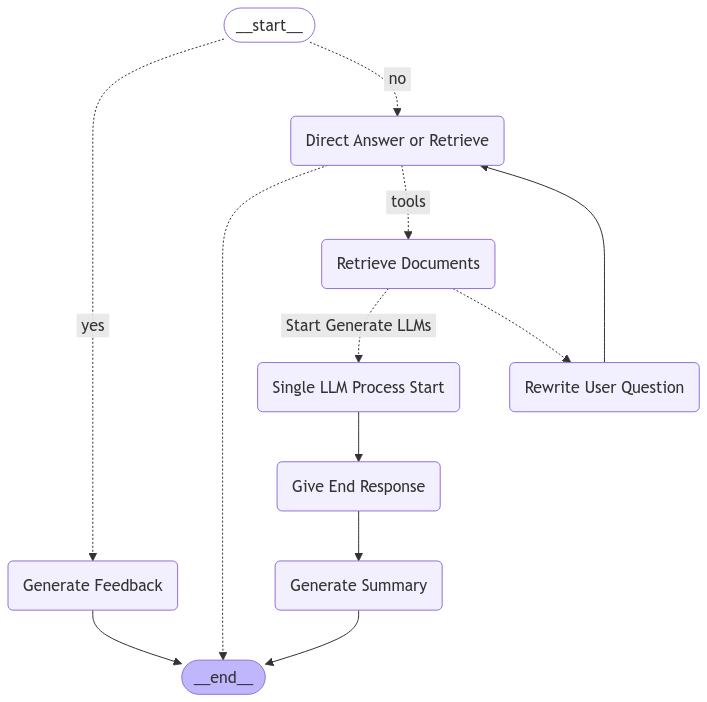

In [86]:
from IPython.display import Image, display

Image(graph.get_graph(xray=1).draw_mermaid_png())   

In [137]:
input_message = " Have all authors listed appropriately and contributed significantly to the research?"

In [138]:
# Create a thread
config = {"configurable": {"thread_id": "5"}}

response = graph.invoke(
        {"questions": [input_message]}, config
)
response["end_responses"][-1]
response["summary"]

"The user inquired whether all authors of a research paper were appropriately listed and significantly contributed to the research. The AI provided multiple responses:\n\n1. The first response indicated that while the authors and their affiliations were listed, specific contributions were not detailed in the provided excerpts. Typically, a separate acknowledgment section would clarify individual contributions.\n   \n2. The second response acknowledged that the authors had diverse backgrounds relevant to the study, suggesting significant contributions, but it also noted the absence of specific details on individual contributions.\n\n3. The third response affirmed that the authors were appropriately acknowledged and had significant contributions, as evidenced by their expertise in areas pertinent to the research topic. It also highlighted the collaborative nature of the work and the paper's emphasis on future research directions.\n\nIn summary, while the authors appear to have diverse ex

In [139]:
input_message = "Is the critical analysis of existing approaches sufficiently deep and insightful? Does the review identify the research gaps that this paper aims to address?"
response = graph.invoke(
        {"questions": [input_message]}, config
)
response["end_responses"][-1]


'1) Answer of gpt-4o : Yes, the critical analysis of existing approaches in the paper appears to be sufficiently deep and insightful. The paper identifies the limitations of traditional rule-based methods, which are inefficient for complex or unknown fraud cases and vulnerable to adversarial attacks. It also highlights research gaps, such as the need for scalable and interpretable models that incorporate both local and global topological features to improve detection accuracy and model interpretability in anti-money laundering efforts.\n 2) Answer of gpt-4o-mini : The paper provides a critical review of existing anti-money laundering (AML) approaches, highlighting their limitations, particularly the inefficiencies of rule-based methods and their vulnerability to evasion by fraudsters. It indicates that prior studies often evaluated their methods on a limited number of datasets, which the authors address by utilizing multiple real and synthetic datasets for a more comprehensive evaluati

In [ ]:
input_message = "what are the questions that i have asked?"
response = graph.invoke(
        {"questions": [input_message]}, config
)
response["end_responses"][-1]

'1) Answer of gpt-4o : The research paper "Scalable Semi-Supervised Graph Learning Techniques for Anti Money Laundering" was authored by Md. Rezaul Karim, Felix Hermsen, Sisay Adugna Chala, Paola De Perthuis, and Avikarsha Mandal from various institutions. The paper critically analyzes current anti-money laundering (AML) approaches, noting challenges such as lack of access to real and labeled financial transaction data, inefficiencies in rule-based systems, and the need for more sophisticated methods to capture complex laundering patterns. The authors propose a novel approach using semi-supervised graph learning to improve AML techniques, emphasizing the importance of incorporating both local and global topological features for better detection and interpretability.\n 2) Answer of gpt-4o-mini : The user inquired about the contributions of the authors in the paper on anti-money laundering (AML) and sought a critical analysis of existing AML approaches. They were interested in understand

In [ ]:
graph.get_state(config).values.get("summary","")

"The user first inquired about the appropriateness of authorship and contributions in a research paper, and the AI provided multiple responses indicating that while authors were listed with relevant expertise, specific contributions were not detailed. It noted a collaborative nature and the emphasis on future research directions.\n\nIn a subsequent question, the user asked whether the critical analysis of existing approaches in a paper was sufficiently deep and insightful, and if it identified research gaps. The AI's responses confirmed that the paper offered a thorough review of existing anti-money laundering (AML) approaches, highlighting the limitations of rule-based methods, particularly their inefficiency in complex fraud cases. It noted that the review identified significant research gaps, emphasizing the need for scalable and interpretable models that incorporate semi-supervised learning techniques. The analysis was described as deep and insightful, laying a foundation for the n

In [ ]:
all_states = []
for state in graph.get_state_history(config):
    print(state)
    all_states.append(state)
    print("--")

StateSnapshot(values={'messages': [], 'questions': ['Is the methodology scientifically sound and well-supported by existing literature?', 'Are the findings of the research adequately discussed and analyzed?', 're the mathematical formulations and algorithms presented correctly and rigorously?', 'Is the literature review comprehensive and up-to-date covering works in graph learning and anti-money laundering adequately cited and discussed?', 'Is the literature review comprehensive and up-to-date covering works in graph learning and anti-money laundering adequately cited and discussed?', 'Is the literature review comprehensive and up-to-date covering works in graph learning and anti-money laundering adequately cited and discussed?', 'Is the literature review comprehensive and up-to-date covering works in graph learning and anti-money laundering adequately cited and discussed?', 'Is the literature review comprehensive and up-to-date covering works in graph learning and anti-money launderin

In [ ]:
to_replay = all_states[2]
to_replay.values

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_zCkRqjqSfMWnZcz90Qeg72m8', 'function': {'arguments': '{"query":"Is the literature review comprehensive and up-to-date covering works in graph learning and anti-money laundering adequately cited and discussed?"}', 'name': 'retrieve'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 85, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72ed7ab54c', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-43453781-e738-4da6-959b-30c0a280231c-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'Is the literature review comprehensive and up-to-date covering works in graph learning and anti-money lau